In [1]:
#!pip install -r requirements.txt

In [1]:
import torch
from torch.utils.data import DataLoader
import optuna
import numpy as np
import pandas as pd
import feature_engineering
from dataset.dataset_construction import TimeSeriesDataset
from model import *

device = 'cuda' if torch.cuda.is_available() else 'cpu'

c:\Users\Usuario\Desktop\CIC\6\CDD\TRABALHO\GIT\Guri-Teimoso\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

In [3]:
file_path = './dataset/dataset.csv'
raw_dataset_df = pd.read_csv(file_path)

df_hybrid = feature_engineering.featureEng(raw_dataset_df)

X_train, y_train, X_test, y_test = feature_engineering.createSplit(df_hybrid)

preprocessor = feature_engineering.createPreprocessingPipeline(X_train.columns)

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

def objective(trial):
    set_seed(42)

    hp = {
        'input_size':  28,
        'output_size': 1,
        'label_width': 1,
        'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
        'num_layers':  trial.suggest_int('num_layers', 1, 5),
        'dropout':     trial.suggest_float('dropout', 0.0, 0.4, step=0.1),
    }

    tp = {
        'batch_size': trial.suggest_categorical('batch_size', [32]),
        'lr':         trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'epochs':     20,
    }

    # Refit preprocessor cleanly for each trial
    trial_preprocessor = feature_engineering.createPreprocessingPipeline(X_train.columns)

    cv_history = crossValidate(
        X_train, y_train,
        hyperparameters=hp,
        preprocessor=trial_preprocessor,
        train_params=tp,
        n_splits=5,
        patience=5,
    )

    # Objective: average best MSE across folds
    mean_mse = np.mean([np.min(h['val_mae']) for h in cv_history])
    return mean_mse

In [5]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nBest MSE : {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/20 [00:06<?, ?it/s]


[W 2026-06-23 17:36:55,309] Trial 0 failed with parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.4, 'batch_size': 32, 'lr': 0.0006552300605279364} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Usuario\Desktop\CIC\6\CDD\TRABALHO\GIT\Guri-Teimoso\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Usuario\AppData\Local\Temp\ipykernel_4196\1667326535.py", line 24, in objective
    cv_history = crossValidate(
                 ^^^^^^^^^^^^^^
  File "c:\Users\Usuario\Desktop\CIC\6\CDD\TRABALHO\GIT\Guri-Teimoso\src\model\model.py", line 56, in crossValidate
    optimizer.step()
  File "c:\Users\Usuario\Desktop\CIC\6\CDD\TRABALHO\GIT\Guri-Teimoso\.venv\Lib\site-packages\torch\optim\optimizer.py", line 535, in wrapper
    out = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Usuario\Desktop\CIC

KeyboardInterrupt: 

In [5]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Drop the NaN rows created by lag shifts
X_train_processed = X_train_processed.dropna()
y_train = y_train.loc[X_train_processed.index]

X_test_processed = X_test_processed.dropna()
y_test = y_test.loc[X_test_processed.index]

train_df = pd.concat([X_train_processed, y_train], axis=1)
test_df  = pd.concat([X_test_processed,  y_test],  axis=1)

train_dataset = TimeSeriesDataset(train_df, input_width=7, label_width=1, shift=1, label_columns=['internacoes'])
test_dataset = TimeSeriesDataset(test_df, input_width=7, label_width=1, shift=1, label_columns=['internacoes'])

train_loader =  DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
hyperparameters = {
    'input_size': 28,
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'label_width': 1,
    'dropout': 0.1
}

train_params = {
    'batch_size': 32,
    'lr': 1e-3,
    'epochs': 45
}

model = LSTMModel(
    input_size=hyperparameters['input_size'],
    hidden_size=hyperparameters['hidden_size'],
    num_layers=hyperparameters['num_layers'],
    output_size=hyperparameters['output_size'],
    label_width=hyperparameters['label_width'],
    dropout=hyperparameters['dropout']
)

model.to(device)

LSTMModel(
  (lstm): LSTM(28, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [7]:
model, history = train(model, train_loader, train_params)
result = evaluate(model, test_loader, device)
print(result)

{'loss': np.float64(5.333915734291077), 'mse': 5.347593784332275, 'mae': 1.893100619316101, 'rmse': np.float64(2.31248649387024), 'r2': 0.24112200736999512}


{'loss': np.float64(4.514227831363678), 'mse': 4.7052435874938965, 'mae': 1.6935983896255493, 'rmse': np.float64(2.169157345029147), 'r2': 0.3322780728340149}




Analisando resultados

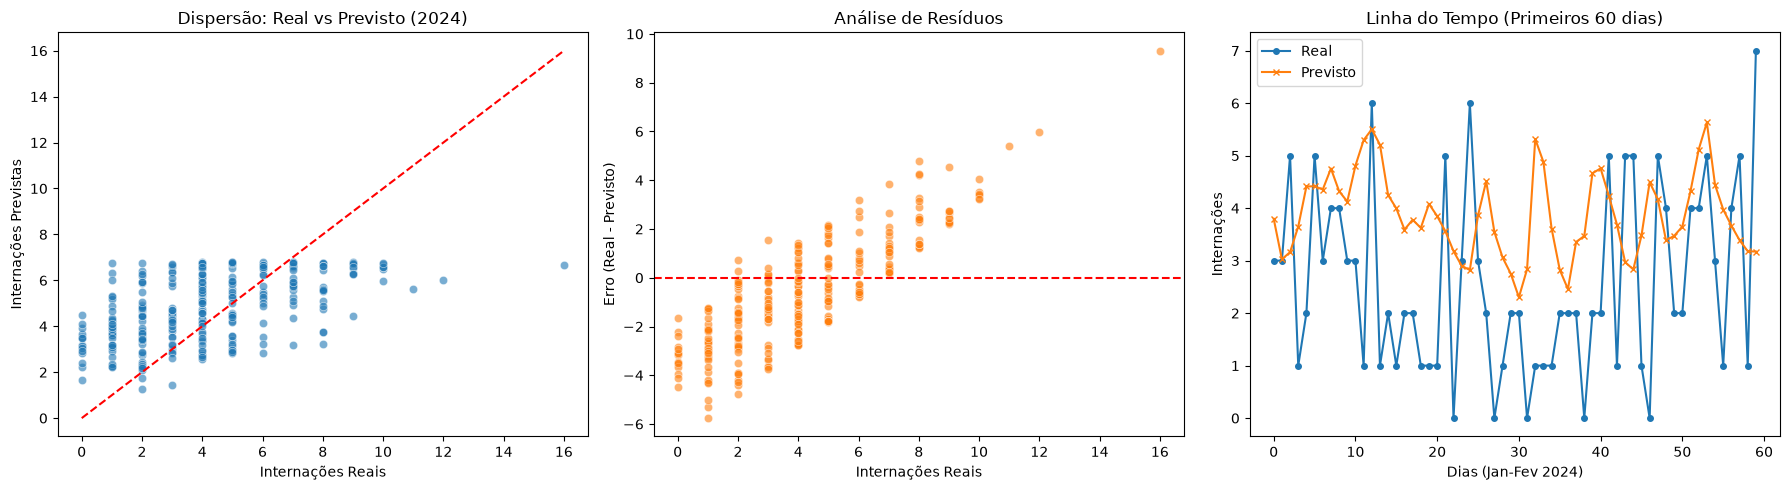

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extrair todas as previsões e valores reais do DataLoader de teste
model.eval()
previsoes_lstm = []
reais_lstm = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs)
        
        # Achata os tensores e move para a CPU
        previsoes_lstm.extend(preds.view(-1).cpu().numpy())
        reais_lstm.extend(labels.view(-1).cpu().numpy())

previsoes_lstm = np.array(previsoes_lstm)
reais_lstm = np.array(reais_lstm)
residuos = reais_lstm - previsoes_lstm

# 2. Configurar a figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Scatter Plot (Real vs Previsto) ---
sns.scatterplot(x=reais_lstm, y=previsoes_lstm, alpha=0.6, ax=axes[0], color='#1f77b4')
# Linha perfeita (onde y_real == y_previsto)
max_val = max(max(reais_lstm), max(previsoes_lstm))
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--')
axes[0].set_title('Dispersão: Real vs Previsto (2024)')
axes[0].set_xlabel('Internações Reais')
axes[0].set_ylabel('Internações Previstas')

# --- PLOT 2: Gráfico de Resíduos ---
sns.scatterplot(x=reais_lstm, y=residuos, alpha=0.6, ax=axes[1], color='#ff7f0e')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Análise de Resíduos')
axes[1].set_xlabel('Internações Reais')
axes[1].set_ylabel('Erro (Real - Previsto)')

# --- PLOT 3: Linha do Tempo (Amostra de 60 dias) ---
# Pegamos apenas os primeiros 60 dias para não poluir o gráfico
dias = 60
axes[2].plot(reais_lstm[:dias], label='Real', marker='o', markersize=4)
axes[2].plot(previsoes_lstm[:dias], label='Previsto', marker='x', markersize=4)
axes[2].set_title(f'Linha do Tempo (Primeiros {dias} dias)')
axes[2].set_xlabel('Dias (Jan-Fev 2024)')
axes[2].set_ylabel('Internações')
axes[2].legend()

plt.tight_layout()
plt.show()

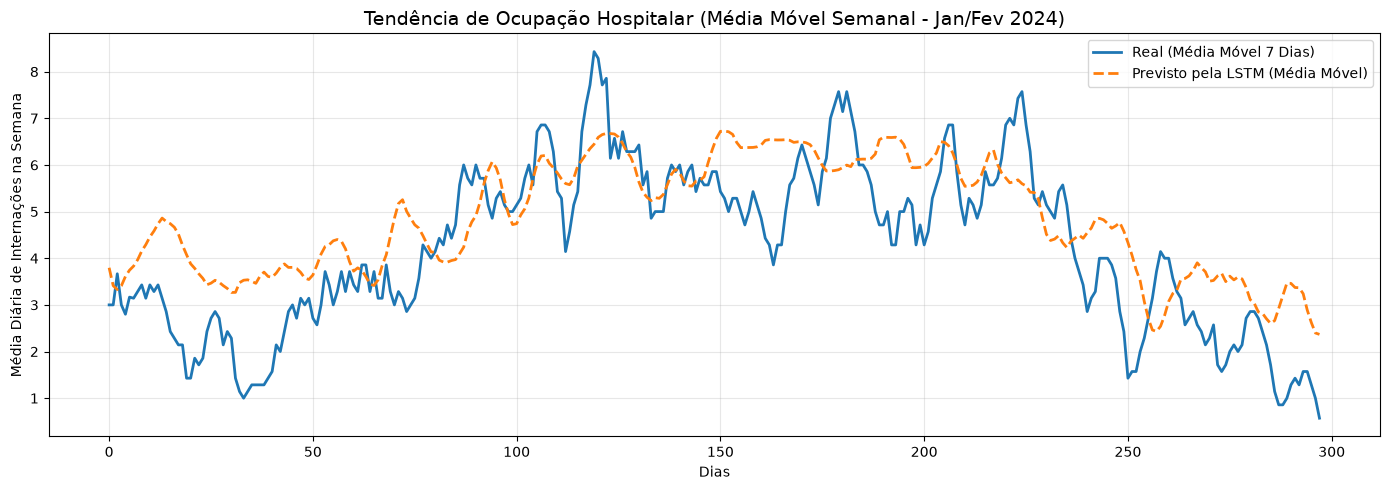

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Colocar os arrays em um DataFrame para facilitar o cálculo da janela
df_analise = pd.DataFrame({
    'Real': reais_lstm,
    'Previsto': previsoes_lstm
})

# 2. Calcular a Média Móvel de 7 dias
# Isso significa: "A ocupação média esperada para a próxima semana"
df_rolling = df_analise.rolling(window=7, min_periods=1).mean()

# 3. Plotar o resultado
plt.figure(figsize=(14, 5))
plt.plot(df_rolling['Real'], label='Real (Média Móvel 7 Dias)', linewidth=2, color='#1f77b4')
plt.plot(df_rolling['Previsto'], label='Previsto pela LSTM (Média Móvel)', linewidth=2, linestyle='--', color='#ff7f0e')

plt.title('Tendência de Ocupação Hospitalar (Média Móvel Semanal - Jan/Fev 2024)', fontsize=14)
plt.xlabel('Dias')
plt.ylabel('Média Diária de Internações na Semana')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SHAP VALUES

n_features after pipeline: 28
X_train_windows shape: (1203, 7, 28)
X_test_windows shape : (298, 7, 28)
raw shap_values shape: (100, 7, 28, 1)
shap_arr shape: (100, 7, 28)
feature_names: 28  |  shap n_features: 28

Top 10 features by mean |SHAP|:
  no2                                  0.069046
  so2                                  0.060574
  precipitacao                         0.052590
  dia_semana                           0.047679
  mes                                  0.046157
  fim_de_semana                        0.046011
  radiacao                             0.040296
  vento_velocidade                     0.032095
  vento_rajada_max                     0.025036
  pressao_atm                          0.022174


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18944\1668105698.py:120: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


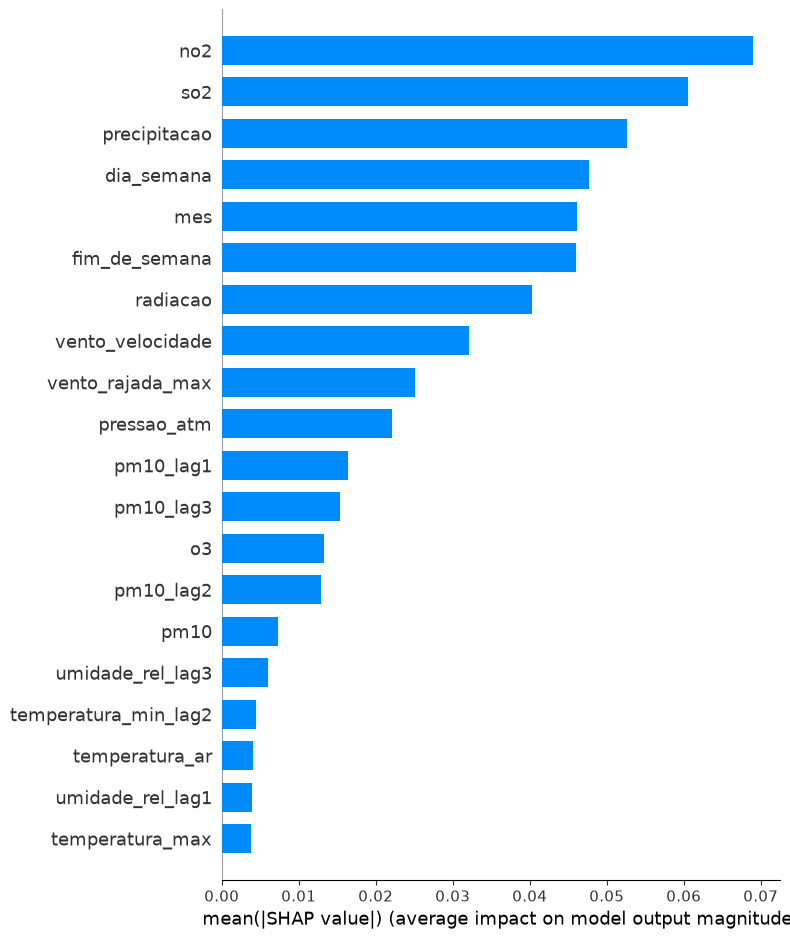

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18944\1668105698.py:128: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


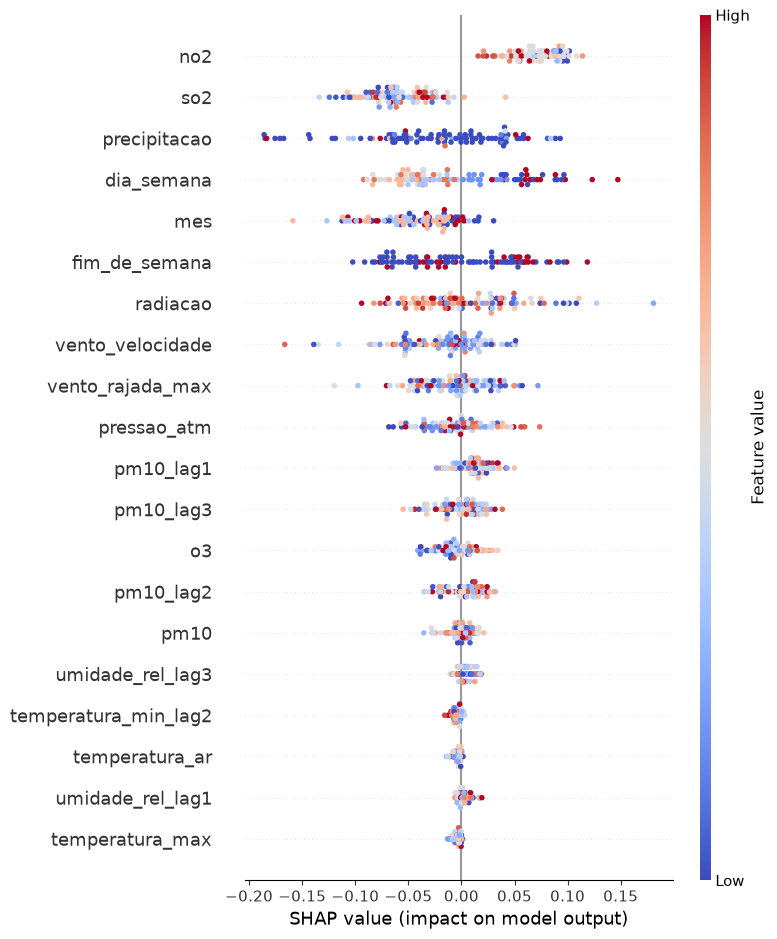

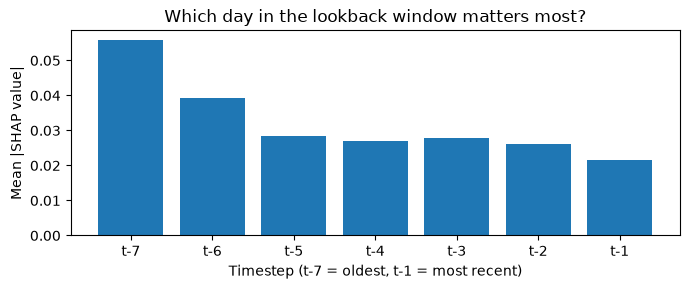

In [10]:
import torch
import numpy as np
import shap

# ── 0. Derive true feature count from the processed DataFrame ─────────────────
# After the pipeline, X_train_processed has shape (n_rows, n_features)
# The TimeSeriesDataset windows it into (batch, input_width=7, n_features)
INPUT_WIDTH = 7
INPUT_SIZE  = X_train_processed.shape[1]   # true feature count, whatever it is
print(f"n_features after pipeline: {INPUT_SIZE}")   # confirm this equals 29

feature_names = X_train_processed.columns.tolist()  # save for plots later


# ── 1. Extract windowed numpy arrays directly from the DataLoader ─────────────
# This guarantees SHAP sees the exact same (batch, 7, n_features) tensors
# that the model was trained on — no manual windowing needed.

def extract_windows(loader, max_samples=None):
    """Pull (X, y) windows out of a DataLoader into numpy arrays."""
    xs = []
    for X_batch, _ in loader:
        xs.append(X_batch.numpy())
        if max_samples and sum(a.shape[0] for a in xs) >= max_samples:
            break
    X_np = np.concatenate(xs, axis=0)
    if max_samples:
        X_np = X_np[:max_samples]
    return X_np   # (n_samples, input_width, input_size)

X_train_windows = extract_windows(train_loader)
X_test_windows  = extract_windows(test_loader)

print("X_train_windows shape:", X_train_windows.shape)  # (n, 7, n_features)
print("X_test_windows shape :", X_test_windows.shape)   # (n, 7, n_features)


# ── 2. Wrapper: flattens model output to (batch,) ────────────────────────────
def model_predict(x_np: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        x_t = torch.tensor(x_np, dtype=torch.float32).to(next(model.parameters()).device)
        out = model(x_t)        # (batch, label_width=1, output_size=1)
        out = out[:, 0, 0]      # → (batch,)
    return out.cpu().numpy().astype(np.float64)


# ── 3. Background sample ──────────────────────────────────────────────────────
n_bg       = 50
bg_indices = np.random.choice(X_train_windows.shape[0], n_bg, replace=False)
background = X_train_windows[bg_indices]   # (50, 7, n_features)


# ── 4. Explainer ──────────────────────────────────────────────────────────────
bg_tensor  = torch.tensor(background, dtype=torch.float32)

class FlatModel(torch.nn.Module):
    def __init__(self, base): super().__init__(); self.base = base
    def forward(self, x): return self.base(x)[:, 0, 0].unsqueeze(1)  # (B, 1)

flat_model = FlatModel(model).eval()
explainer  = shap.GradientExplainer(flat_model, bg_tensor)

X_explain   = torch.tensor(X_test_windows[:100], dtype=torch.float32)
shap_values = explainer.shap_values(X_explain)

# ── 5. Shape normalisation ────────────────────────────────────────────────────
raw = np.array(shap_values)
print("raw shap_values shape:", raw.shape)
# GradientExplainer returns (n_samples, input_width, n_features, n_outputs)

if raw.ndim == 4 and raw.shape[-1] == 1:
    # Squeeze the trailing output dimension → (n_samples, input_width, n_features)
    shap_arr = raw[..., 0]
elif raw.ndim == 3:
    shap_arr = raw
else:
    raise ValueError(f"Unexpected shap_values shape: {raw.shape}")

print("shap_arr shape:", shap_arr.shape)        # expect (100, 7, 29)
n_samples, input_width, n_features = shap_arr.shape

# ── 6. Reconcile feature names ────────────────────────────────────────────────
print(f"feature_names: {len(feature_names)}  |  shap n_features: {n_features}")

if n_features == len(feature_names):
    feature_names_plot = feature_names
elif n_features == len(feature_names) + 1:
    print("WARNING: 'internacoes' is leaking into X — fix TimeSeriesDataset.")
    feature_names_plot = feature_names + ['internacoes']
else:
    raise ValueError(
        f"Cannot reconcile feature_names ({len(feature_names)}) "
        f"with shap_arr n_features ({n_features})"
    )

# ── 7. Aggregate ──────────────────────────────────────────────────────────────
shap_by_feature  = shap_arr.mean(axis=1)               # (100, 29) avg over timesteps
mean_abs_shap    = np.abs(shap_by_feature).mean(axis=0) # (29,)
mean_abs_by_step = np.abs(shap_arr).mean(axis=(0, 2))   # (7,)

ranked = sorted(zip(feature_names_plot, mean_abs_shap), key=lambda x: -x[1])
print("\nTop 10 features by mean |SHAP|:")
for name, val in ranked[:10]:
    print(f"  {name:35s}  {val:.6f}")

X_display = X_test_windows[:100, -1, :]   # (100, 28) — last timestep, all features

# Clean up scaler prefixes from feature names for readability
def clean_name(name):
    return (name
        .replace("minmax__", "")
        .replace("robust__", "")
    )

feature_names_clean = [clean_name(n) for n in feature_names_plot]


# ── 8. Plots ──────────────────────────────────────────────────────────────────
shap.summary_plot(
    shap_by_feature,
    feature_names=feature_names_plot,
    plot_type="bar",
    show=True
)

# ── Beeswarm with proper feature value coloring ───────────────────────────────
shap.summary_plot(
    shap_by_feature,              # (100, 28) — SHAP values
    features=X_display,           # (100, 28) — actual feature values for color scale
    feature_names=feature_names_clean,
    plot_type="dot",
    cmap="coolwarm",              # blue=low, red=high (matches your reference image)
    show=False
)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3))
plt.bar(range(input_width), mean_abs_by_step)
plt.xticks(range(input_width), [f"t-{input_width - i}" for i in range(input_width)])
plt.xlabel("Timestep (t-7 = oldest, t-1 = most recent)")
plt.ylabel("Mean |SHAP value|")
plt.title("Which day in the lookback window matters most?")
plt.tight_layout()
plt.show()


In [10]:
# ── Leakage probe ─────────────────────────────────────────────────────────────
# If internacoes is column -1 of the input window, zeroing it should
# dramatically change predictions. If it's properly excluded, predictions
# should be identical.

model.eval()
with torch.no_grad():
    sample = torch.tensor(X_test_windows[:32], dtype=torch.float32).to(device)

    pred_normal  = model(sample)[:, 0, 0].cpu().numpy()

    # Zero out the last feature across all 7 timesteps
    sample_zeroed = sample.clone()
    sample_zeroed[:, :, -1] = 0.0
    pred_zeroed  = model(sample_zeroed)[:, 0, 0].cpu().numpy()

    max_diff = np.abs(pred_normal - pred_zeroed).max()
    mean_diff = np.abs(pred_normal - pred_zeroed).mean()

    print(f"Max  prediction change after zeroing last feature: {max_diff:.6f}")
    print(f"Mean prediction change after zeroing last feature: {mean_diff:.6f}")

    if mean_diff > 0.01:
        print("LEAK LIKELY — last feature strongly affects output.")
        print("internacoes is probably column -1 of the input window.")
    else:
        print("No leakage detected via last-column zeroing.")

# ── Cross-check: what are the actual column names in the window? ──────────────
# train_df was built as pd.concat([X_train_processed, y_train], axis=1)
# so its columns are: [28 feature cols..., 'internacoes']
print("\ntrain_df columns:")
print(list(train_df.columns))
print(f"\nTotal: {len(train_df.columns)} columns")
print(f"Model input_size hyperparameter: {hyperparameters['input_size']}")

# If TimeSeriesDataset uses ALL columns as input (not just the first 28),
# input_size=29 matches and the target leaks in. The tell:
if hyperparameters['input_size'] == len(train_df.columns):
    print("\nWARNING: input_size == total columns in train_df (including target).")
    print("TimeSeriesDataset is almost certainly feeding internacoes as a feature.")
elif hyperparameters['input_size'] == len(train_df.columns) - 1:
    print("\nOK: input_size == n_feature_cols (target excluded from input).")

Max  prediction change after zeroing last feature: 0.317551
Mean prediction change after zeroing last feature: 0.096498
LEAK LIKELY — last feature strongly affects output.
internacoes is probably column -1 of the input window.

train_df columns:
['temperatura_ar', 'temperatura_orvalho', 'temperatura_min', 'temperatura_max', 'umidade_rel', 'vento_direcao', 'precipitacao', 'pressao_atm', 'radiacao', 'vento_rajada_max', 'vento_velocidade', 'pm10', 'so2', 'no2', 'o3', 'mes', 'dia_semana', 'fim_de_semana', 'inverno', 'temperatura_min_lag1', 'temperatura_min_lag2', 'temperatura_min_lag3', 'umidade_rel_lag1', 'umidade_rel_lag2', 'umidade_rel_lag3', 'pm10_lag1', 'pm10_lag2', 'pm10_lag3', 'internacoes']

Total: 29 columns
Model input_size hyperparameter: 28

OK: input_size == n_feature_cols (target excluded from input).


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18468\1410649066.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


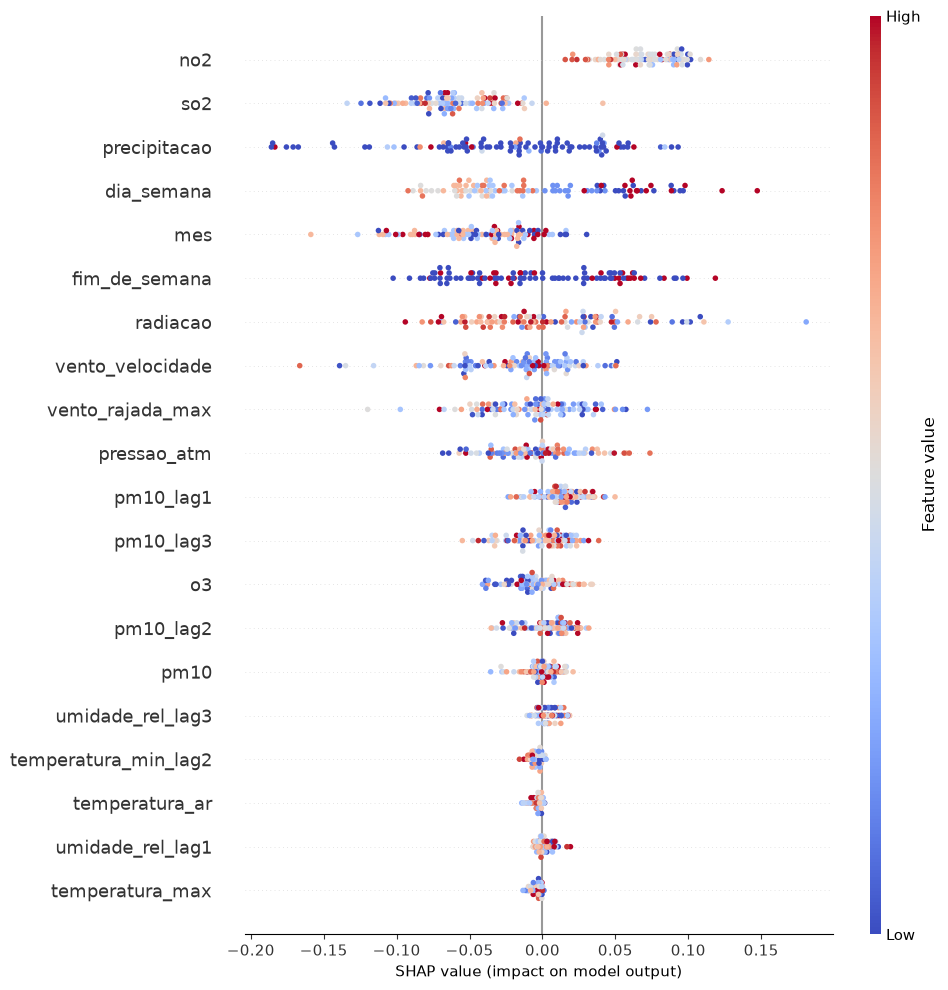

In [12]:
import matplotlib.pyplot as plt

# ── Build X_display: feature values matching the explained samples ────────────
# shap_by_feature is (100, 28) — averaged over the 7 timesteps
# We need the corresponding raw feature values in the same shape

# Take the most recent timestep (t-1) as the representative feature value
# since it's most interpretable and closest to the prediction point
X_display = X_test_windows[:100, -1, :]   # (100, 28) — last timestep, all features

# Clean up scaler prefixes from feature names for readability
def clean_name(name):
    return (name
        .replace("minmax__", "")
        .replace("robust__", "")
    )

feature_names_clean = [clean_name(n) for n in feature_names_plot]

# ── Beeswarm with proper feature value coloring ───────────────────────────────
shap.summary_plot(
    shap_by_feature,              # (100, 28) — SHAP values
    features=X_display,           # (100, 28) — actual feature values for color scale
    feature_names=feature_names_clean,
    plot_type="dot",
    cmap="coolwarm",              # blue=low, red=high (matches your reference image)
    show=False
)

plt.gcf().set_size_inches(10, 10)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()